In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10, mnist

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
def scale_intensity(images):
    """
    Scales image intensities linearly to fall strictly between 50.0 and 200.0
    Formula: 50 + (X - min) * (200 - 50) / (max - min)
    """
    images = images.astype('float32')
    img_min = images.min()
    img_max = images.max()

    return 50.0 + (images - img_min) * (150.0) / (img_max - img_min)

In [3]:
def custom_split(images, seed=42):
    """
    Shuffles and splits a single dataset array into 70% Train, 20% Val, and 10% Test
    """
    np.random.seed(seed)
    indices = np.arange(len(images))
    np.random.shuffle(indices)
    
    num_samples = len(images)
    train_end = int(0.7 * num_samples)
    val_end = int(0.9 * num_samples)
    
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]
    
    return images[train_idx], images[val_idx], images[test_idx]

In [4]:
# Load MNIST
(x_mnist_train_raw, y_train_mnist_raw), (x_mnist_test_raw, y_test_mnist_raw) = mnist.load_data()
mnist_all = np.concatenate((x_mnist_train_raw, x_mnist_test_raw), axis=0)

# Scale intensity to [50, 200]
mnist_all_scaled = scale_intensity(mnist_all)

# Expand dimensions to add the channel axis (28, 28, 1)
mnist_all_scaled = np.expand_dims(mnist_all_scaled, axis=-1)

print(f"Total MNIST shape after processing: {mnist_all_scaled.shape}")
print(f"Intensity Range: {mnist_all_scaled.min():.1f} to {mnist_all_scaled.max():.1f}")

Total MNIST shape after processing: (70000, 28, 28, 1)
Intensity Range: 50.0 to 200.0


In [5]:
# 70/20/10 Split
mnist_train, mnist_val, mnist_test = custom_split(mnist_all_scaled)

print("--- MNIST Final Splits ---")
print(f"Train Dataset:      {mnist_train.shape}")
print(f"Validation Dataset: {mnist_val.shape}")
print(f"Test Dataset:       {mnist_test.shape}")

--- MNIST Final Splits ---
Train Dataset:      (49000, 28, 28, 1)
Validation Dataset: (14000, 28, 28, 1)
Test Dataset:       (7000, 28, 28, 1)


In [17]:
# Load CIFAR-10
(x_cifar_train_raw, y_cifar_train_raw), (x_cifar_test_raw, y_cifar_test_raw) = cifar10.load_data()
cifar_all = np.concatenate((x_cifar_train_raw, x_cifar_test_raw), axis=0)

# Convert RGB to Grayscale using ITU-R 601-2 luma formula
cifar_gray = 0.299 * cifar_all[:, :, :, 0] + 0.587 * cifar_all[:, :, :, 1] + 0.114 * cifar_all[:, :, :, 2]

# Expand dimensions to (num_samples, 32, 32, 1) so tf.image.resize can handle it
cifar_gray = np.expand_dims(cifar_gray, axis=-1)

# Resize from 32x32 to 28x28
cifar_resized = tf.image.resize(cifar_gray, [28, 28]).numpy()

# Scale intensity to [50, 200]
cifar_all_scaled = scale_intensity(cifar_resized)

print(f"Total CIFAR-10 shape after conversion and resizing: {cifar_all_scaled.shape}")
print(f"Intensity Range: {cifar_all_scaled.min():.1f} to {cifar_all_scaled.max():.1f}")

Total CIFAR-10 shape after conversion and resizing: (60000, 28, 28, 1)
Intensity Range: 50.0 to 200.0


In [18]:
# 70/20/10 Split
cifar_train, cifar_val, cifar_test = custom_split(cifar_all_scaled)

print("--- CIFAR-10 Final Splits ---")
print(f"Train Dataset:      {cifar_train.shape}")
print(f"Validation Dataset: {cifar_val.shape}")
print(f"Test Dataset:       {cifar_test.shape}")

--- CIFAR-10 Final Splits ---
Train Dataset:      (42000, 28, 28, 1)
Validation Dataset: (12000, 28, 28, 1)
Test Dataset:       (6000, 28, 28, 1)


In [19]:
# Extract and split labels using the exact same seeding/shuffling strategy from your custom_split
def custom_split_labels(labels, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    
    num_samples = len(labels)
    train_end = int(0.7 * num_samples)
    val_end = int(0.9 * num_samples)
    
    return labels[indices[:train_end]], labels[indices[train_end:val_end]], labels[indices[val_end:]]

In [20]:
# 1. Fetch and process MNIST targets
mnist_labels_all = np.concatenate((y_train_mnist_raw, y_test_mnist_raw), axis=0)
mnist_y_train, _, mnist_y_test = custom_split_labels(mnist_labels_all)

print(f"MNIST Labels -> Train: {mnist_y_train.shape}, Test: {mnist_y_test.shape}")

MNIST Labels -> Train: (49000,), Test: (7000,)


In [21]:
# 2. Fetch and process CIFAR-10 targets
cifar_labels_all = np.concatenate((y_cifar_train_raw, y_cifar_test_raw), axis=0).flatten()
cifar_y_train, _, cifar_y_test = custom_split_labels(cifar_labels_all)

print(f"CIFAR-10 Labels -> Train: {cifar_y_train.shape}, Test: {cifar_y_test.shape}")

CIFAR-10 Labels -> Train: (42000,), Test: (6000,)


In [28]:
# Flatten images from (N, 28, 28, 1) to (N, 784)
X_train_mnist_flat = mnist_train.reshape(mnist_train.shape[0], -1)
X_test_mnist_flat = mnist_test.reshape(mnist_test.shape[0], -1)

X_train_cifar_flat = cifar_train.reshape(cifar_train.shape[0], -1)
X_test_cifar_flat = cifar_test.reshape(cifar_test.shape[0], -1)

def calculate_average_psnr(original, reconstructed):
    """
    Calculates Peak Signal-to-Noise Ratio (PSNR) in dB for reconstructions.
    Using the dynamic range max - min of our normalized data (200 - 50 = 150)
    """
    mse = np.mean((original - reconstructed) ** 2, axis=1)
    mse = np.where(mse == 0, 1e-10, mse) # Avoid log division by zero
    dynamic_range = 150.0 
    psnr = 20 * np.log10(dynamic_range) - 10 * np.log10(mse)
    return np.mean(psnr)

def plot_multiclass_roc(y_test, y_score, title):
    """Plots One-vs-Rest ROC curves for 10 classes"""
    y_test_bin = label_binarize(y_test, classes=list(range(10)))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    plt.figure(figsize=(9, 6))
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
        
    # FIX: Changed 'k--' to '--' to remove the redundant color definition warning
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right", bbox_to_anchor=(1.3, 0.4), fontsize='small')
    plt.tight_layout()
    plt.show()

In [29]:
def run_pca_pipeline(X_train, y_train, X_test, y_test, dataset_name, svd_solver='full'):
    subset_size = int(0.7 * len(X_train))
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]
    
    print(f"\nRunning {svd_solver.upper()} PCA on {dataset_name}...")
    
    # 1. PCA Fit & Transform
    pca = PCA(n_components=30, svd_solver=svd_solver, random_state=42)
    X_train_pca = pca.fit_transform(X_train_subset)
    X_test_pca = pca.transform(X_test)
    
    # 2. Calculate Reconstruction PSNR (Keep raw outputs here so metrics stay pure!)
    X_test_reconstructed = pca.inverse_transform(X_test_pca)
    avg_psnr = calculate_average_psnr(X_test, X_test_reconstructed)
    print(f"-> Average Reconstruction Signal-to-Noise Ratio: {avg_psnr:.4f} dB")
    
    # 3. FIX: Scale the PCA projections to achieve faster classifier convergence
    scaler = StandardScaler()
    X_train_pca_scaled = scaler.fit_transform(X_train_pca)
    X_test_pca_scaled = scaler.transform(X_test_pca)
    
    # 4. Train Logistic Regression Classifier on Scaled Data
    # Concurrently dropped max_iter down to a safe 500 since scaling speeds it up drastically
    clf = LogisticRegression(solver='lbfgs', max_iter=500, random_state=42)
    clf.fit(X_train_pca_scaled, y_train_subset)
    
    # 5. Predict Probabilities using scaled inputs
    y_score = clf.predict_proba(X_test_pca_scaled)
    plot_multiclass_roc(y_test, y_score, f"ROC Curve: {svd_solver.capitalize()} PCA (30 Components) + LogReg on {dataset_name}")
    
    return avg_psnr


Running FULL PCA on MNIST...
-> Average Reconstruction Signal-to-Noise Ratio: 17.7876 dB


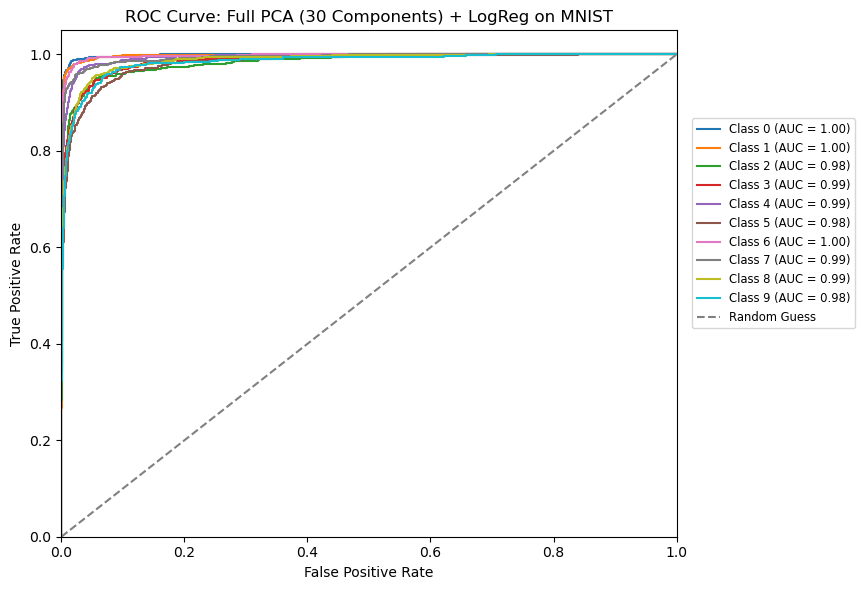


Running RANDOMIZED PCA on MNIST...
-> Average Reconstruction Signal-to-Noise Ratio: 17.7873 dB


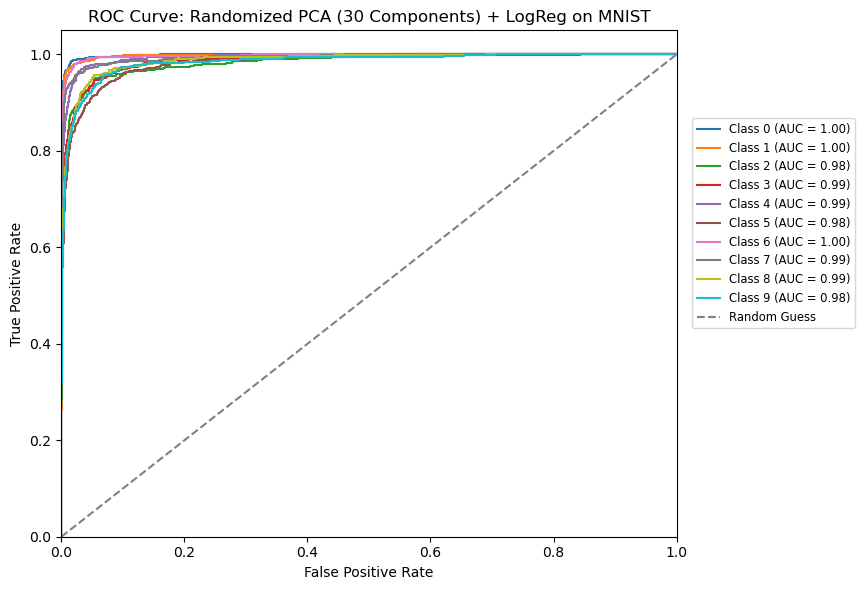

In [30]:
# --- Run on MNIST ---
mnist_std_psnr = run_pca_pipeline(X_train_mnist_flat, mnist_y_train, X_test_mnist_flat, mnist_y_test, "MNIST", svd_solver='full')
mnist_rand_psnr = run_pca_pipeline(X_train_mnist_flat, mnist_y_train, X_test_mnist_flat, mnist_y_test, "MNIST", svd_solver='randomized')


Running FULL PCA on CIFAR-10...
-> Average Reconstruction Signal-to-Noise Ratio: 21.6888 dB


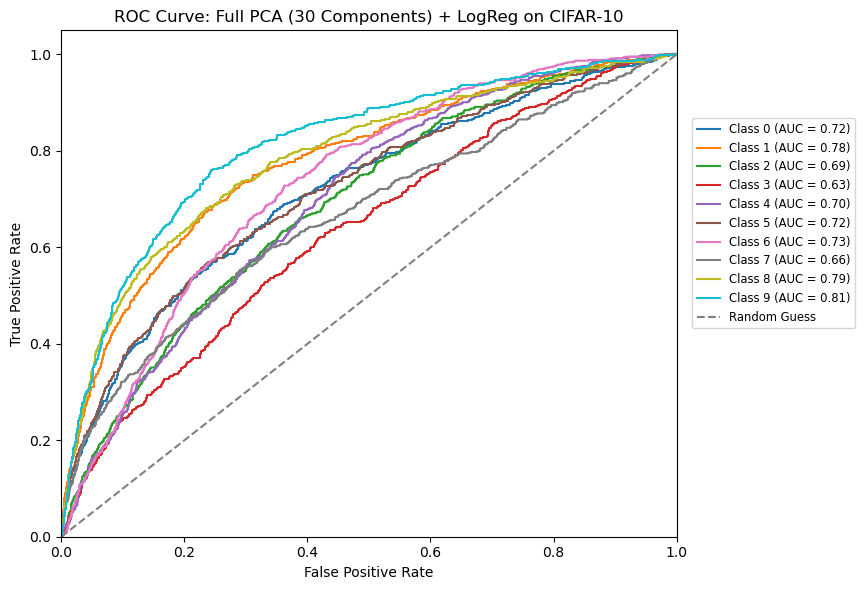


Running RANDOMIZED PCA on CIFAR-10...
-> Average Reconstruction Signal-to-Noise Ratio: 21.6886 dB


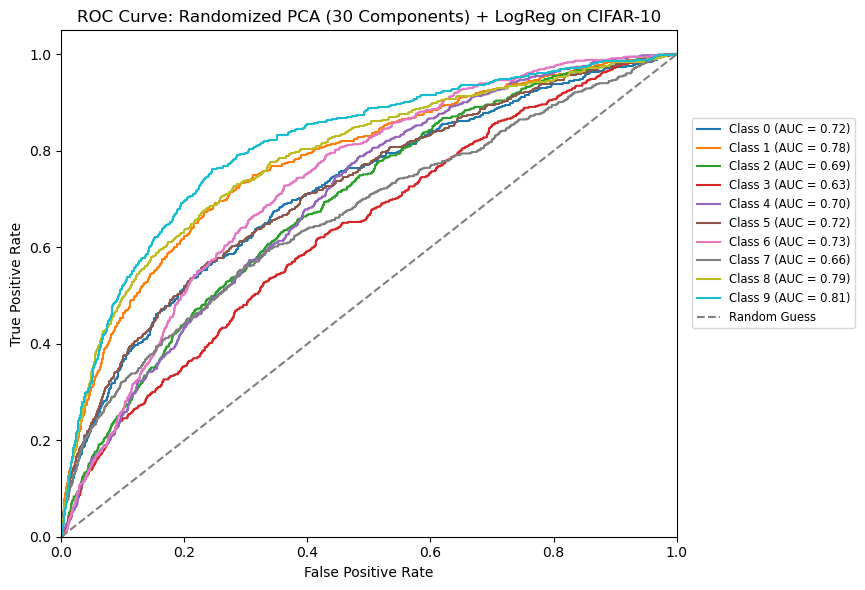

In [31]:
# --- Run on CIFAR-10 ---
cifar_std_psnr = run_pca_pipeline(X_train_cifar_flat, cifar_y_train, X_test_cifar_flat, cifar_y_test, "CIFAR-10", svd_solver='full')
cifar_rand_psnr = run_pca_pipeline(X_train_cifar_flat, cifar_y_train, X_test_cifar_flat, cifar_y_test, "CIFAR-10", svd_solver='randomized')

In [32]:
print("=========================== SUMMARY REPORT ===========================")
print(f"MNIST Standard PCA Reconstructed PSNR:      {mnist_std_psnr:.4f} dB")
print(f"MNIST Randomized PCA Reconstructed PSNR:    {mnist_rand_psnr:.4f} dB")
print(f"MNIST PSNR Absolute Delta:                  {abs(mnist_std_psnr - mnist_rand_psnr):.6f} dB\n")
print(f"CIFAR-10 Standard PCA Reconstructed PSNR:   {cifar_std_psnr:.4f} dB")
print(f"CIFAR-10 Randomized PCA Reconstructed PSNR: {cifar_rand_psnr:.4f} dB")
print(f"CIFAR-10 PSNR Absolute Delta:               {abs(cifar_std_psnr - cifar_rand_psnr):.6f} dB")
print("======================================================================")

=========================== SUMMARY REPORT ===========================
MNIST Standard PCA Reconstructed PSNR:      17.7876 dB
MNIST Randomized PCA Reconstructed PSNR:    17.7873 dB
MNIST PSNR Absolute Delta:                  0.000298 dB

CIFAR-10 Standard PCA Reconstructed PSNR:   21.6888 dB
CIFAR-10 Randomized PCA Reconstructed PSNR: 21.6886 dB
CIFAR-10 PSNR Absolute Delta:               0.000147 dB
